# 0.38 — Monthly-rebalance backtest, with a size floor

**The rule, in full:**

```
basket   →   drop every name under $MIN_CAP market cap on the entry date
         →   equal weight, hold 1 month, rebalance, repeat
         →   compare against SPY run through the identical machinery
```

One parameter: `MIN_CAP`. Everything below is evidence for it, not a new rule.

**Conventions** (unchanged from 0.35, so the numbers stay comparable to Federico's).
Per period $i$, over the names $H_i$ that have a price at $t_i$:

$$r_i = \tfrac{1}{|H_i|}\sum_{j \in H_i}\Bigl(\tfrac{P_j(t_{i+1})}{P_j(t_i)} - 1\Bigr)
\qquad R = \sum_i r_i \qquad \text{ret/risk} = R/\sigma \qquad
\text{Sharpe}_{ann} = \frac{\overline{r - r_f}}{\sigma_{r - r_f}} \cdot \sqrt{12/m}$$

Periods are contiguous — each exit day *is* the next entry day. $P$ = Yahoo adjusted close.

`Sharpe` is a **true** Sharpe ratio: $r_f$ is the 13-week US T-bill yield (`^IRX`) quoted at the
start of each holding period, applied for that period's length — the return of doing nothing.
It averaged 4.5%/yr over both windows. Subtracting it costs the volatile baskets almost nothing
(0.97 → 0.95) and the index a lot (1.76 → 1.39), because the same ~0.38%/month comes off every
mean while the denominators differ by a factor of fifteen. `ret/risk` keeps deck 8's convention
and takes no $r_f$, so it stays comparable to Federico's tables.

**Two choices made explicit, both one line to reverse:**

1. The basket is fixed at the entry date and the floor is applied **once, there**. Re-testing
   the floor every month would quietly turn it into a momentum rule that sells whatever fell.
2. A name whose size cannot be resolved at all is **dropped**, and printed by name. Keeping an
   unknown-size name inside a size filter defeats the filter.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # theme_* modules live in code/scripts/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import theme_backtest as bt
import theme_basket as tb
import theme_features as tf

# ---- the two parameters ------------------------------------------------------
MIN_CAP = 200.0        # $m, market cap on the entry date
HOLD    = 1            # months held between rebalances
END     = "2025-12-31"
GRAY    = "#7a7a75"

THEMES = {"quantum": dict(name="quantum_2022-09-30", start="2022-09-30", color="#2a78d6"),
          "genAI":   dict(name="genai_2023-01-17",   start="2023-01-17", color="#eb6834")}

# the list deck 8 backtested, kept so every number here has a predecessor to compare to
DECK8 = {"quantum": ["IONQ", "QUBT", "RGTI", "QBTS"],
         "genAI":   ["NVDA", "TRIP", "GOOG", "EA", "MYPS", "APPS",
                     "EXPE", "EBAY", "CRNC", "FFAI"]}

PROC = Path.cwd().parent / "data" / "processed"


def baskets(theme, top_n=10):
    '''The three construction rules of 0.36, plus the list deck 8 actually traded.'''
    n = THEMES[theme]["name"]
    b = pd.read_parquet(PROC / f"theme_basket_{n}.parquet")
    m = json.loads((PROC / f"theme_basket_{n}_manifest.json").read_text())
    out = {"1 count":    b.sort_values(["n_terms_hit", "per_1k_words"], ascending=False),
           "2 density":  b,
           "3 weighted": tb.rank_specificity(b, m)}
    d = {k: v.ticker.head(top_n).tolist() for k, v in out.items()}
    d["deck 8"] = DECK8[theme]
    return d


B = {t: baskets(t) for t in THEMES}
UNIVERSE = sorted({x for th in B.values() for v in th.values() for x in v} | {"SPY"})
px = bt.load_prices(UNIVERSE, verbose=False)
print(f"{len(UNIVERSE)} tickers, prices for {px.shape[1]}")

32 tickers, prices for 32


## 1 · What we are buying

Before any return: every candidate, with the one number the floor reads and the one number
that says whether a position could have been built at all. `in` marks which construction
rules picked the name; **bold** rows are in the list deck 8 traded.

In [2]:
def candidates(theme):
    '''Every name any rule picked, with its size and liquidity on the entry date.'''
    start = THEMES[theme]["start"]
    names = list(dict.fromkeys([t for v in B[theme].values() for t in v]))
    s = tf.basket_sheet(names, start, px, verbose=False)
    s["in"] = ["".join(k[0] for k in ("1 count", "2 density", "3 weighted") if t in B[theme][k])
               for t in s.ticker]
    s["deck8"] = np.where(s.ticker.isin(B[theme]["deck 8"]), "*", "")
    s["keep"] = s.cap_musd.astype(float).fillna(-1) >= MIN_CAP
    cols = ["ticker", "deck8", "in", "name", "price", "cap_musd", "addv_med_musd", "keep"]
    out = s[cols].rename(columns={"cap_musd": "cap $m", "addv_med_musd": "$m traded/day",
                                  "name": "company"})
    out["company"] = out.company.str.slice(0, 26)
    return out.sort_values(["keep", "cap $m"], ascending=False)


CAND = {}
for theme in THEMES:
    CAND[theme] = candidates(theme)
    print(f"\n=== {theme} — as of {THEMES[theme]['start']} "
          f"— floor ${MIN_CAP:,.0f}m ===")
    print(CAND[theme].to_string(index=False, na_rep="?",
                                float_format=lambda v: f"{v:,.2f}"))


=== quantum — as of 2022-09-30 — floor $200m ===
ticker deck8  in                    company  price     cap $m  $m traded/day  keep
   HON         3 Honeywell International In 166.97 103,253.10         445.63  True
   IBM        13 International Business Mac 118.81  92,439.70         488.24  True
  MRSH        13 Marsh & McLennan Companies 149.29  69,864.20         247.27  True
  IONQ     * 123                 IonQ, Inc.   5.07   1,010.00          14.24  True
  QBTS     * 123        D-Wave Quantum Inc.   7.87     865.80           1.31  True
   QSI         2    Quantum-Si incorporated   2.75     383.30           1.32  True
  RBBN         1 Ribbon Communications Inc.   2.22     371.90           1.10  True
  RGTI     * 123    Rigetti Computing, Inc.   1.88     228.10           2.21  True
  QMCO         2        Quantum Corporation   1.08     110.90           0.36 False
  QUBT     * 123     Quantum Computing Inc.   2.51      85.10           0.54 False
  GEOS         2 Geospace Technologie


=== genAI — as of 2023-01-17 — floor $200m ===
ticker deck8  in                    company    price       cap $m  $m traded/day  keep
  GOOG     * 123              Alphabet Inc.    92.16 1,177,085.30       2,341.79  True
  NVDA     * 123         NVIDIA Corporation   177.02   440,155.90       6,965.28  True
   AMD         2 Advanced Micro Devices, In    71.59   115,428.80       4,439.98  True
   TJX         2    The TJX Companies, Inc.    81.55    89,565.30         385.06  True
  BKNG        12      Booking Holdings Inc. 2,334.02    88,652.10         640.91  True
  ABNB         3               Airbnb, Inc.   101.27    64,121.80         512.46  True
  EBAY     *  13                  eBay Inc.    46.77    23,814.10         217.32  True
  SIRI         2    Sirius XM Holdings Inc.     5.98    20,323.80          81.55  True
  EXPE     *  13        Expedia Group, Inc.   106.55    16,427.70         219.87  True
  TRIP     * 123          Tripadvisor, Inc.    21.69     3,049.30          38.11  

In [3]:
def apply_floor(theme, tickers, verbose=True):
    '''Keep the names above MIN_CAP on the entry date; report what went and why.'''
    c = CAND[theme].set_index("ticker")
    kept, small, unknown = [], [], []
    for t in tickers:
        if t not in c.index:
            unknown.append(t); continue
        cap = c.loc[t, "cap $m"]
        (unknown if not np.isfinite(cap) else kept if cap >= MIN_CAP else small).append(t)
    if verbose and (small or unknown):
        bits = []
        if small:   bits.append("under the floor: " + ", ".join(small))
        if unknown: bits.append("size unresolved, dropped: " + ", ".join(unknown))
        print("   " + " | ".join(bits))
    return kept


FILTERED = {}
for theme in THEMES:
    print(f"\n{theme}")
    FILTERED[theme] = {}
    for label, tk in B[theme].items():
        print(f"  {label:<11} {len(tk):>2} ->", end=" ")
        keep = apply_floor(theme, tk, verbose=False)
        FILTERED[theme][label] = keep
        print(f"{len(keep):>2}  {', '.join(keep)}")
        apply_floor(theme, tk)


quantum
  1 count     10 ->  6  IONQ, RGTI, QBTS, IBM, RBBN, MRSH
   under the floor: QUBT, LODE, AMPG | size unresolved, dropped: BZAI
  2 density   10 ->  4  IONQ, QBTS, RGTI, QSI
   under the floor: QUBT, QMCO, GEOS, LODE, AMPG | size unresolved, dropped: BZAI
  3 weighted  10 ->  6  IONQ, QBTS, RGTI, MRSH, HON, IBM
   under the floor: QUBT, LODE, AMPG | size unresolved, dropped: BZAI
  deck 8       4 ->  3  IONQ, RGTI, QBTS
   under the floor: QUBT

genAI
  1 count     10 ->  9  NVDA, TRIP, GOOG, MYPS, APPS, EXPE, EBAY, CRNC, BKNG
   under the floor: FFAI
  2 density   10 ->  8  GOOG, NVDA, TJX, MYPS, BKNG, AMD, SIRI, TRIP
   under the floor: CSPI | size unresolved, dropped: OKLO
  3 weighted   9 ->  7  NVDA, GOOG, TRIP, EXPE, ABNB, EBAY, CRNC
   under the floor: FFAI | size unresolved, dropped: OKLO
  deck 8      10 ->  8  NVDA, TRIP, GOOG, MYPS, APPS, EXPE, EBAY, CRNC
   under the floor: FFAI | size unresolved, dropped: EA


## 2 · The backtest

Equal weight, hold `HOLD` months, rebalance, from the theme's entry date to `END`.
SPY goes through the same function, so the benchmark row is not a different calculation.

In [4]:
def stats(tickers, start, months=HOLD, end=END):
    '''Federico's summed-return convention, plus the two diagnostics deck 9 added.'''
    r, tot, ratio = bt.rebalance_backtest(px, tickers, start, end, months=months)
    curve = bt.rebalance_curve(px, tickers, start, end, months=months)
    sd = float(r.std(ddof=1))
    return {"n": len(tickers), "periods": len(r), "sum R": tot,
            "compounded": float(curve.iloc[-1] - 1), "std": sd,
            "ret/risk": ratio, "Sharpe ann": bt.sharpe(px, tickers, start, end, months=months),
            "max DD": bt.max_drawdown(curve),
            "best period": float(r.max() / tot) if tot else np.nan}


def plot_curves(theme, months=HOLD):
    cfg = THEMES[theme]
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    series = [(f"deck 8 ({len(B[theme]['deck 8'])})", B[theme]["deck 8"], "#d62728", ":", 1.8),
              (f"deck 8, filtered ({len(FILTERED[theme]['deck 8'])})",
               FILTERED[theme]["deck 8"], cfg["color"], "-", 2.0),
              (f"3 weighted, filtered ({len(FILTERED[theme]['3 weighted'])})",
               FILTERED[theme]["3 weighted"], "#2ca02c", "-", 1.6),
              ("SPY", ["SPY"], GRAY, "--", 1.5)]
    ends = []
    for label, tk, col, ls, lw in series:
        if not tk:
            continue
        c = bt.rebalance_curve(px, tk, cfg["start"], END, months=months)
        ax.plot(c.index, c, color=col, ls=ls, lw=lw, label=label)
        ends.append([np.log10(c.iloc[-1]), c.index[-1], f" {c.iloc[-1] - 1:+.0%}", col])
    ends.sort(key=lambda e: -e[0])
    for i in range(1, len(ends)):                      # keep the end labels apart
        ends[i][0] = min(ends[i][0], ends[i - 1][0] - 0.075)
    for y, x, text, col in ends:
        ax.annotate(text, (x, 10 ** y), color=col, fontsize=9, fontweight="bold", va="center")
    ax.set_yscale("log"); ax.set_yticks([0.25, 0.5, 1, 2, 4, 8, 16, 32])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}x"))
    ax.grid(alpha=0.25, lw=0.5); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{theme} — equal weight, {months}m rebalance, from {cfg['start']}  "
                 f"(floor ${MIN_CAP:,.0f}m, log scale)", fontsize=11)
    ax.legend(frameon=False, loc="upper left", fontsize=9); ax.margins(x=0.16)
    plt.tight_layout(); plt.show()

### 2.1 · quantum

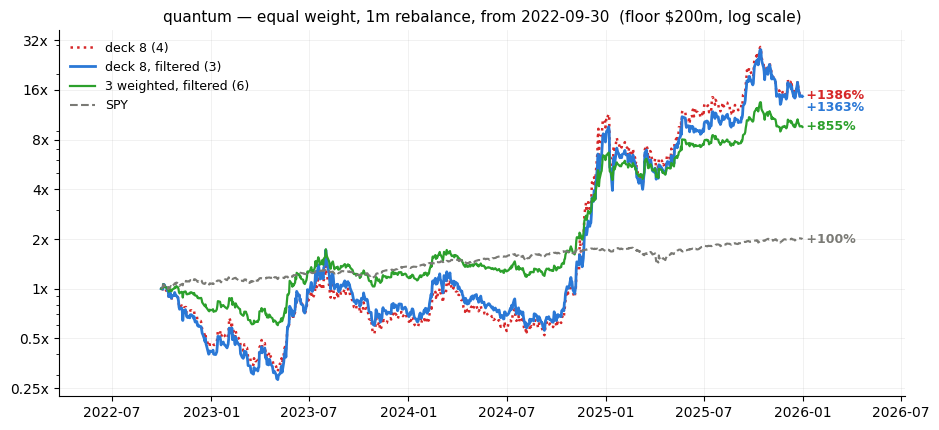

In [5]:
plot_curves("quantum")

### 2.2 · genAI

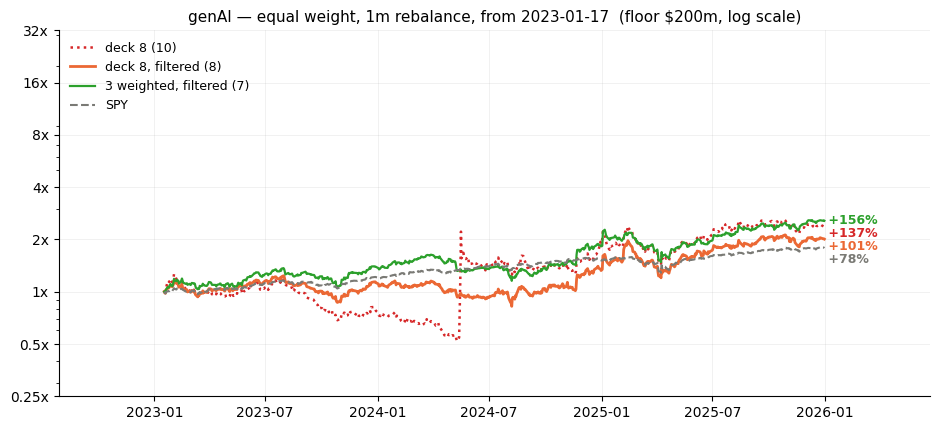

In [6]:
plot_curves("genAI")

## 3 · The numbers

Every basket, before and after the floor, against SPY on the same window.

- **sum R** is Federico's convention (period returns added, not compounded); **compounded** is
  what the curve above actually ends at. They diverge when one period dominates.
- **best period** is that period's share of `sum R`. A basket whose best month is 80% of the
  total did not have a strategy, it had a day.

In [7]:
def table(theme, months=HOLD):
    start = THEMES[theme]["start"]
    rows = {}
    for label, tk in B[theme].items():
        rows[label] = stats(tk, start, months)
        keep = FILTERED[theme][label]
        if keep and set(keep) != set(tk):
            rows[f"{label}  +floor"] = stats(keep, start, months)
    rows["SPY"] = stats(["SPY"], start, months)
    df = pd.DataFrame(rows).T
    df[["n", "periods"]] = df[["n", "periods"]].astype(int)
    return df


FMT = {"sum R": "{:+.1%}".format, "compounded": "{:+.1%}".format, "std": "{:.1%}".format,
       "ret/risk": "{:.2f}".format, "Sharpe ann": "{:.2f}".format,
       "max DD": "{:.1%}".format, "best period": "{:.0%}".format}

for theme in THEMES:
    print(f"\n=== {theme} — from {THEMES[theme]['start']}, {HOLD}m rebalance ===")
    print(table(theme).to_string(formatters=FMT))


=== quantum — from 2022-09-30, 1m rebalance ===


                     n  periods   sum R compounded   std ret/risk Sharpe ann max DD best period
1 count             10       40 +325.0%    +668.1% 29.7%    10.94       0.90 -48.7%         44%
1 count  +floor      6       40 +336.9%    +888.7% 26.7%    12.64       1.05 -44.8%         34%
2 density           10       40 +373.3%    +547.4% 38.4%     9.73       0.81 -64.9%         50%
2 density  +floor    4       40 +485.6%    +670.1% 47.5%    10.22       0.86 -69.8%         44%
3 weighted          10       40 +321.6%    +648.9% 29.6%    10.86       0.90 -49.1%         45%
3 weighted  +floor   6       40 +331.3%    +855.1% 26.4%    12.54       1.04 -43.4%         34%
deck 8               4       40 +610.9%   +1386.5% 54.5%    11.21       0.95 -70.3%         35%
deck 8  +floor       3       40 +602.1%   +1363.3% 52.8%    11.41       0.96 -73.5%         38%
SPY                  1       40  +72.1%     +99.5%  3.5%    20.32       1.39 -18.8%         13%

=== genAI — from 2023-01-17, 1m rebalan

                     n  periods   sum R compounded   std ret/risk Sharpe ann max DD best period
1 count             10       36 +168.5%    +148.0% 27.6%     6.10       0.54 -52.7%         92%
1 count  +floor      9       36  +87.4%    +107.8%  8.9%     9.77       0.79 -36.8%         29%
2 density           10       36 +105.3%    +156.1%  7.7%    13.73       1.15 -29.8%         22%
2 density  +floor    8       36  +62.9%     +75.6%  6.0%    10.56       0.79 -27.8%         31%
3 weighted           9       36 +228.4%    +309.9% 29.1%     7.84       0.71 -45.8%         72%
3 weighted  +floor   7       36 +109.3%    +156.3%  9.1%    12.04       1.01 -35.0%         24%
deck 8              10       36 +176.9%    +136.5% 30.5%     5.80       0.51 -58.9%         97%
deck 8  +floor       8       36  +86.6%    +101.0%  9.8%     8.84       0.71 -38.9%         32%
SPY                  1       36  +60.8%     +78.3%  3.8%    16.19       1.20 -18.8%         21%


## 4 · Does the floor help?

Read the two tables above and answer per theme, not in general — the two themes fail
differently and one answer will not cover both.

In [8]:
for theme in THEMES:
    t = table(theme)
    for label in B[theme]:
        if f"{label}  +floor" not in t.index:
            continue
        a, b_ = t.loc[label], t.loc[f"{label}  +floor"]
        print(f"{theme:<8} {label:<11} "
              f"n {int(a.n):>2} -> {int(b_.n):<2}   "
              f"ret/risk {a['ret/risk']:>5.2f} -> {b_['ret/risk']:<5.2f}   "
              f"max DD {a['max DD']:>7.1%} -> {b_['max DD']:<7.1%}   "
              f"best period {a['best period']:>4.0%} -> {b_['best period']:<4.0%}")
    print()

quantum  1 count     n 10 -> 6    ret/risk 10.94 -> 12.64   max DD  -48.7% -> -44.8%    best period  44% -> 34% 
quantum  2 density   n 10 -> 4    ret/risk  9.73 -> 10.22   max DD  -64.9% -> -69.8%    best period  50% -> 44% 
quantum  3 weighted  n 10 -> 6    ret/risk 10.86 -> 12.54   max DD  -49.1% -> -43.4%    best period  45% -> 34% 
quantum  deck 8      n  4 -> 3    ret/risk 11.21 -> 11.41   max DD  -70.3% -> -73.5%    best period  35% -> 38% 



genAI    1 count     n 10 -> 9    ret/risk  6.10 -> 9.77    max DD  -52.7% -> -36.8%    best period  92% -> 29% 
genAI    2 density   n 10 -> 8    ret/risk 13.73 -> 10.56   max DD  -29.8% -> -27.8%    best period  22% -> 31% 
genAI    3 weighted  n  9 -> 7    ret/risk  7.84 -> 12.04   max DD  -45.8% -> -35.0%    best period  72% -> 24% 
genAI    deck 8      n 10 -> 8    ret/risk  5.80 -> 8.84    max DD  -58.9% -> -38.9%    best period  97% -> 32% 



## 5 · Is the answer robust, or did we pick a lucky floor?

One number per cell — `ret/risk`, with the number of names that survive the floor in
brackets. If a conclusion only holds at one setting of `MIN_CAP` it is not a conclusion.

In [9]:
def sensitivity(theme, floors=(0, 100, 200, 500), holds=(1, 3)):
    start = THEMES[theme]["start"]
    c = CAND[theme].set_index("ticker")["cap $m"]
    out = {}
    for floor in floors:
        for months in holds:
            col = f"${floor:,.0f}m / {months}m"
            col_vals = {}
            for label, tk in B[theme].items():
                keep = tk if floor <= 0 else [t for t in tk if t in c.index
                                              and np.isfinite(c[t]) and c[t] >= floor]
                if not keep:
                    col_vals[label] = "--"
                    continue
                s = stats(keep, start, months)
                col_vals[label] = f"{s['ret/risk']:.2f} ({len(keep)})"
            out[col] = col_vals
    return pd.DataFrame(out)


for theme in THEMES:
    print(f"\n=== {theme} — ret/risk (names kept) ===")
    print(sensitivity(theme).to_string())


=== quantum — ret/risk (names kept) ===


              $0m / 1m   $0m / 3m $100m / 1m $100m / 3m $200m / 1m $200m / 3m $500m / 1m $500m / 3m
1 count     10.94 (10)  4.21 (10)  12.64 (6)   4.64 (6)  12.64 (6)   4.64 (6)  13.07 (4)   5.48 (4)
2 density    9.73 (10)  3.95 (10)   9.25 (5)   3.90 (5)  10.22 (4)   4.23 (4)  11.54 (2)   5.02 (2)
3 weighted  10.86 (10)  4.22 (10)  12.54 (6)   4.66 (6)  12.54 (6)   4.66 (6)  13.23 (5)   5.54 (5)
deck 8       11.21 (4)   4.11 (4)  11.41 (3)   4.44 (3)  11.41 (3)   4.44 (3)  11.54 (2)   5.02 (2)

=== genAI — ret/risk (names kept) ===


              $0m / 1m   $0m / 3m $100m / 1m $100m / 3m $200m / 1m $200m / 3m $500m / 1m $500m / 3m
1 count      6.10 (10)  3.96 (10)   9.77 (9)   5.32 (9)   9.77 (9)   5.32 (9)   9.77 (9)   5.32 (9)
2 density   13.73 (10)  7.55 (10)  10.56 (8)   5.19 (8)  10.56 (8)   5.19 (8)  10.56 (8)   5.19 (8)
3 weighted    7.84 (9)   5.90 (9)  12.04 (7)   6.54 (7)  12.04 (7)   6.54 (7)  12.04 (7)   6.54 (7)
deck 8       5.80 (10)  3.70 (10)   8.84 (8)   4.86 (8)   8.84 (8)   4.86 (8)   8.84 (8)   4.86 (8)


### What the run says

**genAI — the floor works, and it is the whole story.** Every basket's single worst property was
concentration: deck 8's best month was **97% of its total return**, method 1's was 92%. Removing
the names under \$200m takes that to **32% and 29%**, cuts max drawdown from -59% to -39%, and
raises `ret/risk` from 5.80 to 8.84 and the Sharpe from 0.51 to 0.71. The return that survives is smaller and real. The one
exception is `2 density`, which gets *worse* (13.73 -> 10.56): its unfiltered basket was already
mostly large caps, so the floor removes diversification rather than noise (Sharpe 1.15 -> 0.79).

**quantum — the floor helps a little and changes nothing that matters.** `ret/risk` improves
(10.94 -> 12.64), Sharpe 0.90 -> 1.05, and drawdown eases, but the concentration stays high (44% -> 34%) because
quantum's problem was never one bad name. All four survivors re-rated together in late 2024.
And the filtered basket is 6 names of which 3 — IBM, Honeywell, Marsh & McLennan — are large caps
that have nothing to do with the theme.

**The floor is robust.** In the grid, quantum improves monotonically from \$0m to \$500m at both
holding periods, and genAI's improvement appears at \$100m and does not move after — every name
it removes is under \$100m, so the exact level is not a tuned parameter. Both themes are much
better at a 1-month hold than at 3 months, which is the opposite of what deck 8 used.

**The uncomfortable row.** On Sharpe, SPY is **1.39** (quantum window) and **1.20** (genAI
window), against a best basket of 1.05 and 1.01. Same on `ret/risk`: 20.32 and 16.19 against
12.64 and 12.04. **No basket beats the index risk-adjusted** — they beat it on total return only,
by taking three to fifteen times the volatility. Worth saying out loud before these numbers
travel.